# Return-rate plots — one example of each type, with algorithm filtering

Loads one dimension's **precomputed** return-rate data (from
`return_rate_calculation.py`) and shows one example of each plot type inline,
instead of running the full `return_rate_plotting.py` sweep over all dimensions.

**Filtering:** the cached matrices/history contain *all* algorithms; filtering
happens only at plot time via the `ALGOS` variable in the setup cell. Set it to
`None` to show everything, or to a list of names to narrow the view.

**Prerequisite:** run `python return_rate_calculation.py` first so the CSVs in
`data/return_rate/dim_{d}/` exist.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import return_rate_plotting as rp
from return_rate_calculation import RR_DATA_DIR

# ---- knobs ----
DIM = 2
SPECIFIED_PROBLEM = rp.SPECIFIED_PROBLEM   # the single-problem heatmap (e.g. "F17_I1")

# Algorithm filter for all plots below. None -> all 28 algorithms;
# or a list, e.g. the WOA/GWO family:
#   ["HI_WOA","OriginalWOA","WhaleFOA","GWO_WOA","OriginalGWO","IGWO","RW_GWO"]
ALGOS = ["JADE", "SADE", "OriginalSHADE", "L_SHADE", "OriginalDE",
         "OriginalGWO", "IGWO", "RW_GWO",
         "WhaleFOA", "OriginalCSA", "OriginalMFO"]

In [16]:
data_dir = f"{RR_DATA_DIR}/dim_{DIM}"

per_alg = pd.read_csv(f"{data_dir}/per_algorithm_revisits.csv", index_col=0)
matrix_problem = rp._load_matrix(f"{data_dir}/matrix_{SPECIFIED_PROBLEM}.csv")
matrix_p = rp._load_matrix(f"{data_dir}/matrix_problem.csv")
matrix_pc = rp._load_matrix(f"{data_dir}/matrix_problem_class.csv")
matrix_p_w = rp._load_matrix(f"{data_dir}/matrix_problem_weighted.csv")

print("per_algorithm_revisits:", per_alg.shape)
print("matrix_problem:", matrix_problem.shape)
print("matrix_p (avg over problems):", matrix_p.shape)
matrix_p.head()

per_algorithm_revisits: (28, 1)
matrix_problem: (28, 28)
matrix_p (avg over problems): (28, 28)


,AugmentedAEO,GWO_WOA,HI_WOA,IGWO,ImprovedBSO,JADE,L_SHADE,LevyTWO,ModifiedAEO,OriginalAEO,...,OriginalMPA,OriginalMRFO,OriginalNMRA,OriginalSHADE,OriginalSSA,OriginalSSpiderA,OriginalWOA,RW_GWO,SADE,WhaleFOA
AugmentedAEO,1.000000,0.208363,0.168260,0.210217,0.135818,0.192509,0.187372,0.054577,0.255589,0.264024,...,0.181562,0.262789,0.113706,0.191153,0.167678,0.084644,0.179226,0.217050,0.187318,0.030477
GWO_WOA,0.208363,1.000000,0.244417,0.406213,0.342469,0.382888,0.385235,0.086426,0.336564,0.314161,...,0.317854,0.389723,0.219239,0.385744,0.272284,0.138722,0.248178,0.383277,0.360793,0.041418
HI_WOA,0.168260,0.244417,1.000000,0.243119,0.208358,0.240326,0.232590,0.080369,0.230949,0.228113,...,0.206432,0.256845,0.152035,0.233247,0.202284,0.101991,0.246131,0.227217,0.225481,0.041046
IGWO,0.210217,0.406213,0.243119,1.000000,0.324828,0.384982,0.382119,0.101324,0.323453,0.304852,...,0.325267,0.390491,0.226135,0.384137,0.248051,0.139777,0.241707,0.369502,0.374008,0.047143
ImprovedBSO,0.135818,0.342469,0.208358,0.324828,1.000000,0.367503,0.375240,0.110442,0.251988,0.224777,...,0.289563,0.302752,0.222324,0.377080,0.236963,0.174585,0.205762,0.298575,0.364591,0.058409


In [17]:
# helper: filter a similarity MATRIX (rows AND columns) to a subset of algorithms.
# For a matrix you slice both axes; for the per-algorithm barplot table you slice rows.
def filter_matrix(matrix, algorithms):
    if algorithms is None:
        return matrix
    keep = [a for a in matrix.index if a in set(algorithms)]
    missing = [a for a in algorithms if a not in matrix.index]
    if missing:
        print(f"  [warning] not in matrix: {missing}")
    return matrix.loc[keep, keep]

def filter_peralg(per_alg, algorithms):
    if algorithms is None:
        return per_alg
    return per_alg[per_alg.index.isin(algorithms)]

## 1. `plot_mean_rr_problem` — single-problem heatmap
Pairwise shared revisit rate between algorithms for one specific problem/instance.

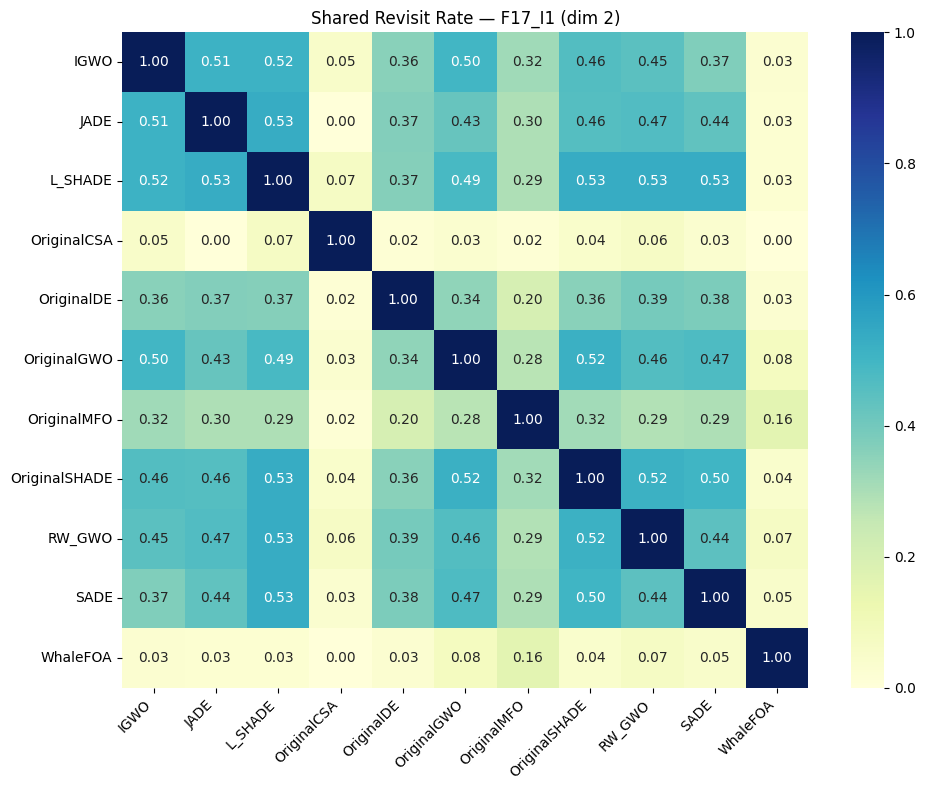

In [18]:
m = filter_matrix(matrix_problem, ALGOS)

plt.figure(figsize=(10, 8))
sns.heatmap(m, annot=(m.shape[0] <= 12), fmt='.2f', cmap='YlGnBu')
plt.title(f'Shared Revisit Rate — {SPECIFIED_PROBLEM} (dim {DIM})')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. `plot_mean_rr` — averaged-over-problems heatmap
Same pairwise similarity, but averaged across all problems (the `matrix_problem.csv`).

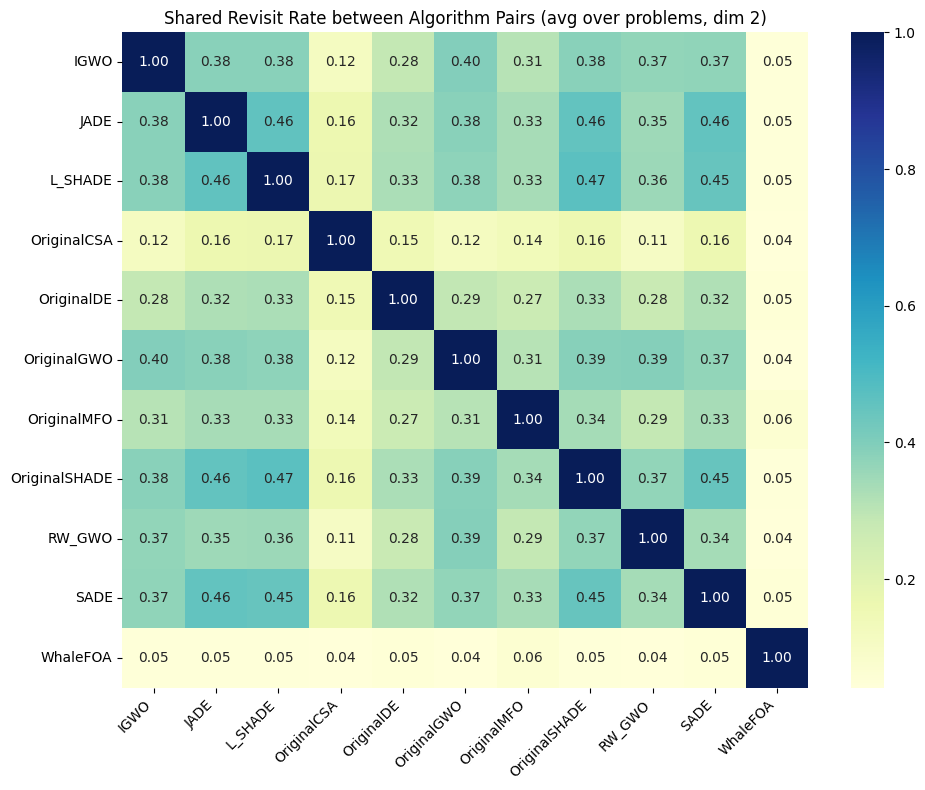

In [19]:
m = filter_matrix(matrix_p, ALGOS)

plt.figure(figsize=(10, 8))
sns.heatmap(m, annot=(m.shape[0] <= 12), fmt='.2f', cmap='YlGnBu')
plt.title(f'Shared Revisit Rate between Algorithm Pairs (avg over problems, dim {DIM})')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. `plot_revisits` — total revisits per algorithm 
How many revisit events each algorithm produced overall.

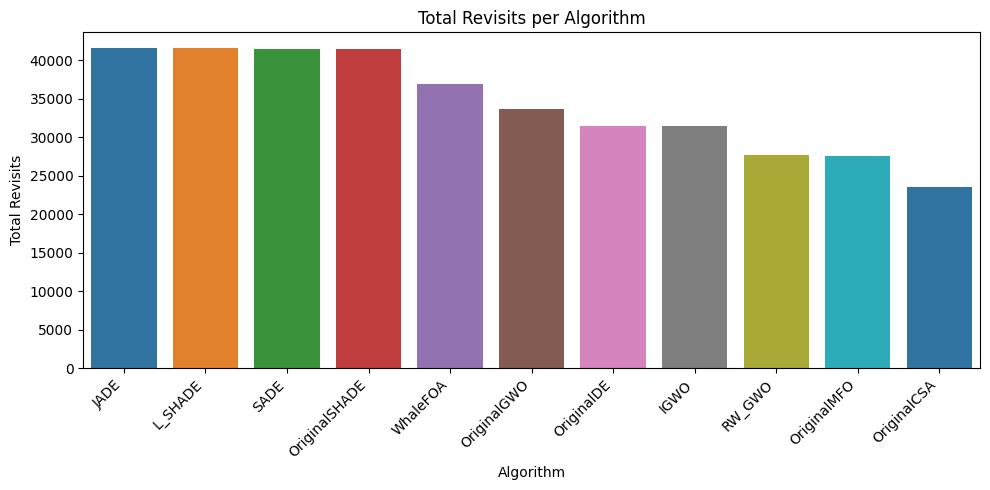

In [20]:
pa = filter_peralg(per_alg, ALGOS).sort_values('total_revisits', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=pa.reset_index(), x='algorithm', y='total_revisits',
            hue='algorithm', palette='tab10', legend=False, ax=ax)
ax.set_title('Total Revisits per Algorithm')
ax.set_xlabel('Algorithm'); ax.set_ylabel('Total Revisits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. `plot_mds` — MDS behavioral map
Projects the pairwise-distance matrix (1 − similarity) into 2D, colored by algorithm family.
With a filtered subset the layout changes (MDS is fit only on the kept algorithms).

/home/boobsson/Desktop/Analiza in vizualizacija algoritmov za optimizacijo prek iskalnih trajektorij/venv/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


normalized stress (Kruskal stress-1): 0.281094769662622


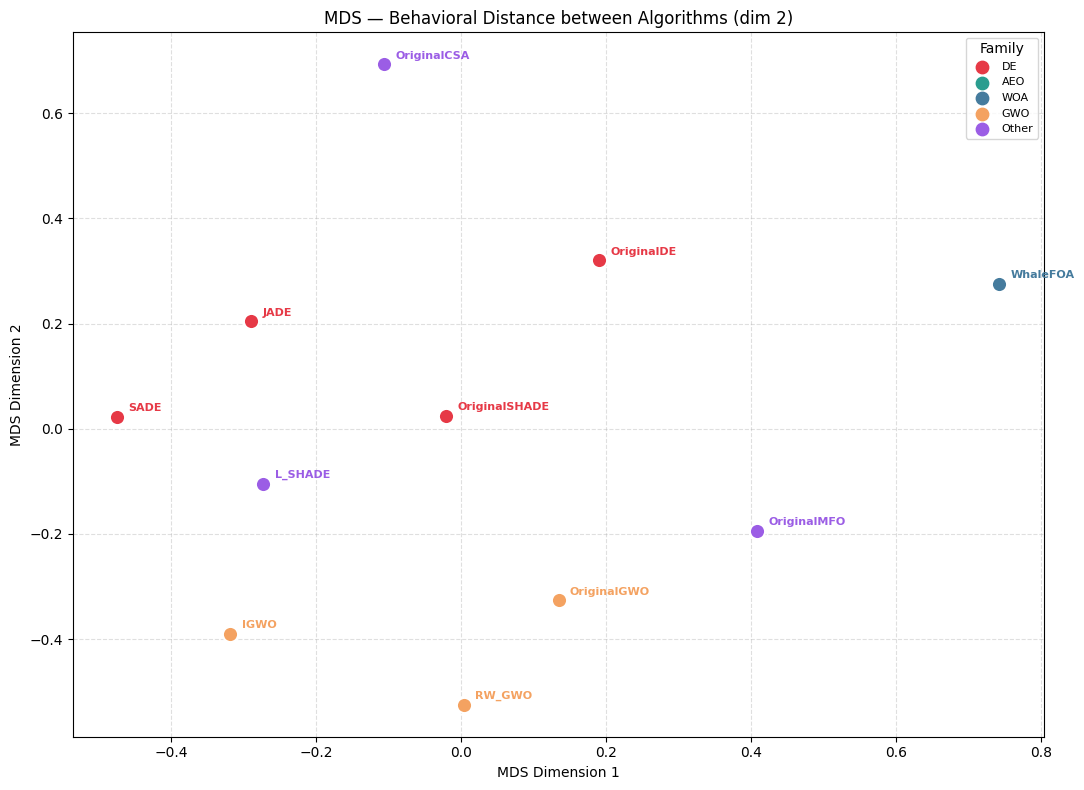

In [21]:
from sklearn.manifold import MDS

m = filter_matrix(matrix_p, ALGOS)

distance_matrix = (1 - m.astype(float)).fillna(1.0)
dist_vals = distance_matrix.values.copy()  # ensure writable
np.fill_diagonal(dist_vals, 0.0)

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
coords = mds.fit_transform(dist_vals)
raw_stress = mds.stress_
# Kruskal's stress-1 = sqrt(raw_stress / sum of squared original distances)
dist_sq_sum = (dist_vals ** 2).sum() / 2   # /2 because the matrix is symmetric
normalized_stress = np.sqrt(raw_stress / dist_sq_sum)
print("normalized stress (Kruskal stress-1):", normalized_stress)
family_map = {
    'DE': ['JADE','OriginalDE','SADE','OriginalSHADE'],
    'AEO': ['ModifiedAEO','OriginalAEO','AugmentedAEO'],
    'WOA': ['OriginalWOA','HI_WOA','WhaleFOA','GWO_WOA'],
    'GWO': ['OriginalGWO','IGWO','RW_GWO'],
    'Other': ['OriginalSSA','OriginalMFO','OriginalHHO','OriginalMPA','OriginalMRFO'],
}
palette = {'DE':'#e63946','AEO':'#2a9d8f','WOA':'#457b9d','GWO':'#f4a261','Other':'#9b5de5'}
def fam(a):
    for f, members in family_map.items():
        if a in members: return f
    return 'Other'

fig, ax = plt.subplots(figsize=(11, 8))
for i, alg in enumerate(m.index):
    c = palette[fam(alg)]
    ax.scatter(coords[i,0], coords[i,1], color=c, s=120, zorder=3, edgecolors='white', linewidths=1.5)
    ax.annotate(alg, (coords[i,0], coords[i,1]), textcoords="offset points", xytext=(8,4),
                fontsize=8, color=c, fontweight='bold')
for f, c in palette.items():
    ax.scatter([], [], color=c, label=f, s=80)
ax.legend(title='Family', fontsize=8)
ax.set_title(f'MDS — Behavioral Distance between Algorithms (dim {DIM})')
ax.set_xlabel('MDS Dimension 1'); ax.set_ylabel('MDS Dimension 2')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Weighted vs unweighted heatmap (Similarity, not distance)
`matrix_problem_weighted.csv` uses per-cluster revisit *counts* (weighted Jaccard) instead
of just distinct clusters. Side by side shows how much weighting shifts the picture.

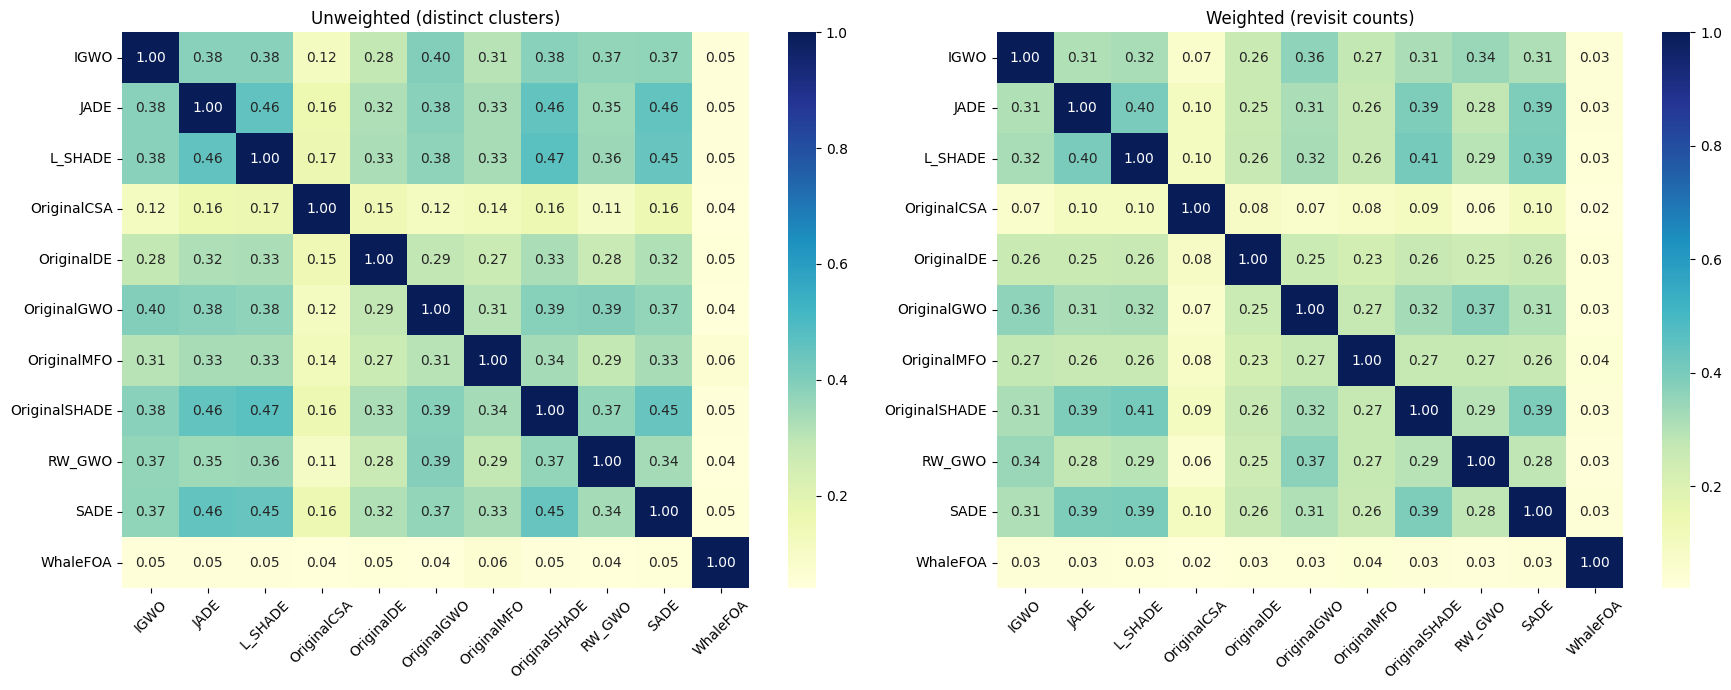

In [22]:
m_unw = filter_matrix(matrix_p, ALGOS)
m_w = filter_matrix(matrix_p_w, ALGOS)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(m_unw, annot=(m_unw.shape[0] <= 12), fmt='.2f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Unweighted (distinct clusters)')
axes[0].tick_params(axis='x', rotation=45)
sns.heatmap(m_w, annot=(m_w.shape[0] <= 12), fmt='.2f', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Weighted (revisit counts)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Dendrogram

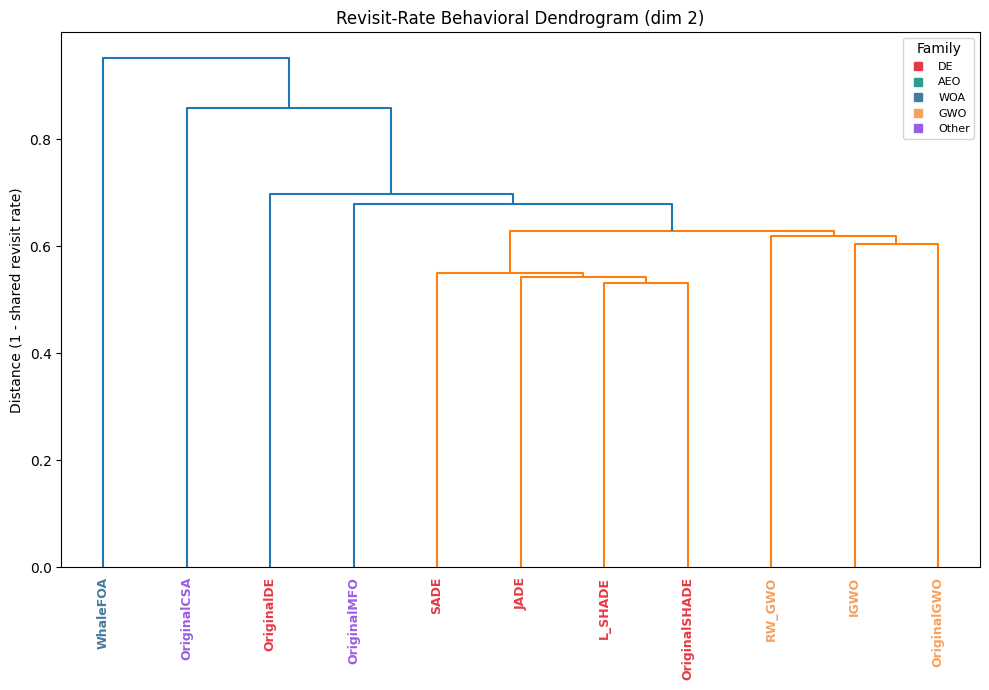

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

m = filter_matrix(matrix_p, ALGOS)

# distance = 1 - similarity, symmetric, zero diagonal
dist = 1.0 - m.astype(float)
dist_vals = dist.values.copy()
np.fill_diagonal(dist_vals, 0.0)
dist_vals = (dist_vals + dist_vals.T) / 2
dist_vals = np.nan_to_num(dist_vals, nan=1.0)

Z = linkage(squareform(dist_vals, checks=False), method='average')

family_map = {
    'DE': ['JADE','OriginalDE','SADE','OriginalSHADE','L_SHADE'],
    'AEO': ['ModifiedAEO','OriginalAEO','AugmentedAEO'],
    'WOA': ['OriginalWOA','HI_WOA','WhaleFOA','GWO_WOA'],
    'GWO': ['OriginalGWO','IGWO','RW_GWO'],
}
palette = {'DE':'#e63946','AEO':'#2a9d8f','WOA':'#457b9d','GWO':'#f4a261','Other':'#9b5de5'}
def fam(a):
    for f, members in family_map.items():
        if a in members: return f
    return 'Other'

fig, ax = plt.subplots(figsize=(max(10, len(m)*0.5), 7))
dendrogram(Z, labels=list(m.index), ax=ax, leaf_rotation=90)
for lbl in ax.get_xticklabels():
    lbl.set_color(palette[fam(lbl.get_text())]); lbl.set_fontweight('bold'); lbl.set_fontsize(9)
for f, c in palette.items():
    ax.plot([], [], color=c, label=f, marker='s', linestyle='None')
ax.legend(title='Family', fontsize=8)
ax.set_title(f'Revisit-Rate Behavioral Dendrogram (dim {DIM})')
ax.set_ylabel('Distance (1 - shared revisit rate)')
plt.tight_layout()
plt.show()